In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [3]:
# Load SEER data
df_seer = pd.read_csv(r"C:\Rishit\Projects\Cancer-Analysis\data\raw\seer\seer_data.txt", 
                      low_memory=False)

# Rename columns
df_seer.columns = ['age', 'sex', 'year', 'race', 'primary_site', 'stage', 'survival_months', 'vital_status']

# Filter for breast cancer only
df_breast = df_seer[df_seer['primary_site'].str.contains('Breast', na=False)].copy()

# Convert survival months
df_breast['survival_months'] = pd.to_numeric(df_breast['survival_months'], errors='coerce')

# Create 5-year survival target (1 = survived 5 years, 0 = did not)
df_breast['survived_5yr'] = ((df_breast['survival_months'] >= 60) | 
                              (df_breast['vital_status'] == 'Alive')).astype(int)

# Remove unknowns
df_ml = df_breast[
    (df_breast['race'] != 'Unknown') &
    (df_breast['stage'].isin(['Localized', 'Regional', 'Distant'])) &
    (df_breast['survival_months'].notna())
].copy()

print(f"Patients for ML: {df_ml.shape[0]}")
print(f"\n5-year survival breakdown:")
print(df_ml['survived_5yr'].value_counts())

Patients for ML: 149275

5-year survival breakdown:
survived_5yr
1    104982
0     44293
Name: count, dtype: int64


In [4]:
# Encode categorical variables
le = LabelEncoder()
df_ml['race_encoded'] = le.fit_transform(df_ml['race'])
df_ml['stage_encoded'] = le.fit_transform(df_ml['stage'])
df_ml['sex_encoded'] = le.fit_transform(df_ml['sex'])

# Clean age column (it's a range like "40-44 years", extract the first number)
df_ml['age_clean'] = df_ml['age'].str.extract(r'(\d+)').astype(float)

# Select features
features = ['age_clean', 'race_encoded', 'stage_encoded', 'sex_encoded']
X = df_ml[features].dropna()
y = df_ml.loc[X.index, 'survived_5yr']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set: {X_test.shape[0]} patients")

Training set: 119420 patients
Test set: 29855 patients


In [5]:
# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model Performance:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

Model Performance:
              precision    recall  f1-score   support

           0       0.73      0.56      0.63      8895
           1       0.83      0.91      0.87     20960

    accuracy                           0.81     29855
   macro avg       0.78      0.73      0.75     29855
weighted avg       0.80      0.81      0.80     29855

ROC-AUC Score: 0.824


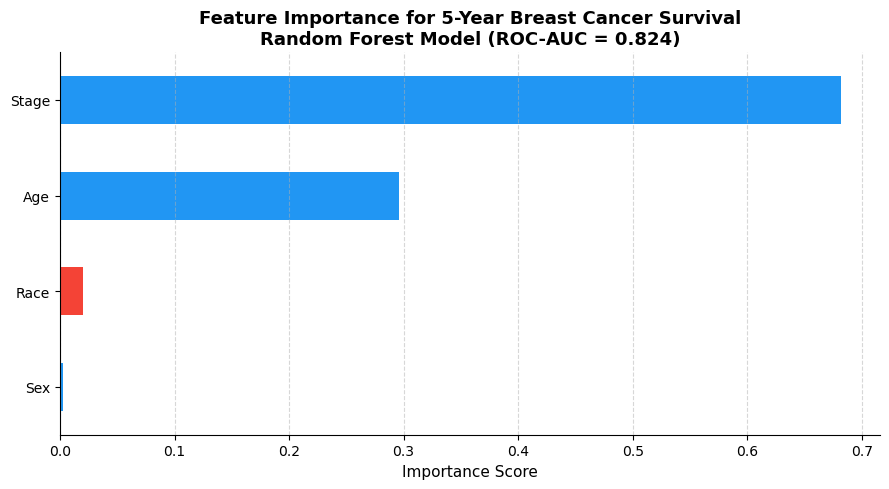

In [10]:
# Fix the labels - sort them correctly
importances = pd.Series(model.feature_importances_, index=['Age', 'Race', 'Stage', 'Sex'])
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#F44336' if i == 'Race' else '#2196F3' for i in importances.index]
importances.plot(kind='barh', ax=ax, color=colors)

ax.set_title('Feature Importance for 5-Year Breast Cancer Survival\nRandom Forest Model (ROC-AUC = 0.824)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(r'C:\Rishit\Projects\Cancer-Analysis\figures\feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()